# 03 — Modélisation & Évaluation — Prédiction du trafic IDFM
## Comparaison de 4 modèles de régression

---

**Objectif** : Prédire `NB_VALD` (nombre de validations) du lendemain pour chaque arrêt.
On compare 4 modèles, on analyse chacun en profondeur (overfitting, métriques, résidus),
puis on sélectionne le meilleur selon : **R² > 0.85 + RMSE minimum + pas d'overfitting**.

### Pourquoi de la régression et pas de la classification ?
Dans le projet diabète on prédisait **0 ou 1** (diabétique ou non) → classification.
Ici on prédit un **nombre continu** (ex: 12 450 validations) → régression.
Les métriques sont donc complètement différentes.

### Les 4 modèles comparés
| Modèle | Rôle | Pourquoi |
|---|---|---|
| **Régression Linéaire** | Baseline | Référence simple — si les autres ne font pas mieux, problème |
| **Decision Tree** | Référence arbre simple | Comprendre les splits de base |
| **Random Forest** | Ensemble robuste | Moyenne de 100 arbres — réduit l'overfitting |
| **XGBoost** | Champion attendu | Gradient boosting — meilleur sur données tabulaires |

### Métriques utilisées
- **RMSE** (Root Mean Squared Error) : erreur en nombre de validations — métrique principale
- **MAE** (Mean Absolute Error) : erreur absolue moyenne — complémentaire
- **R²** : proportion de variance expliquée (0→1, objectif > 0.85)

### Split temporel (pas aléatoire !)
On ne peut pas mélanger aléatoirement une série temporelle.
On ne peut pas utiliser le futur pour prédire le passé.
```
Jours 1 → 74  (80%) → TRAIN
Jours 75 → 92 (20%) → TEST
```

---
## 1. Imports & Configuration

In [2]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# Seuils pour détecter overfitting/underfitting
# Si R² train - R² test > OVERFIT_SEUIL → overfitting
OVERFIT_SEUIL = 0.05
# Objectif R² minimum sur le test
R2_OBJECTIF = 0.85

print('Imports OK')

Imports OK


---
## 2. Chargement des données & Split temporel

### Pourquoi un split temporel ?
Notre dataset est une **série temporelle** — les données sont ordonnées dans le temps.
On ne peut pas mélanger aléatoirement comme dans le projet diabète car :
- On ne peut pas utiliser le trafic du 15 septembre pour prédire celui du 1er août
- En production, on prédit toujours le futur depuis le passé
- Un split aléatoire donnerait des métriques trop optimistes (data leakage)

In [3]:
# Chargement du Parquet produit à l'Étape 3
# POURQUOI LE PARQUET ET PAS MYSQL DIRECTEMENT ?
# Le Parquet contient déjà toutes les features calculées
# (lags, rolling mean, is_weekend...) — pas besoin de les recalculer
df = pd.read_parquet('../data/processed/idfm_features.parquet')
df['JOUR'] = pd.to_datetime(df['JOUR'])
df = df.sort_values(['LIBELLE_ARRET', 'JOUR']).reset_index(drop=True)

print(f'Dataset chargé : {df.shape[0]:,} lignes, {df.shape[1]} colonnes')
print(f'Période : {df["JOUR"].min().date()} → {df["JOUR"].max().date()}')
print(f'Arrêts  : {df["LIBELLE_ARRET"].nunique()}')

# ============================================================
# FEATURES ET VARIABLE CIBLE
# ============================================================
# Ce sont les 12 features qu'on a créées à l'Étape 3
# On n'inclut PAS LIBELLE_ARRET (texte) ni JOUR (datetime)
# car XGBoost ne peut pas les utiliser directement
FEATURES = [
    'jour_semaine',       # 0=Lundi ... 6=Dimanche
    'is_weekend',         # True/False
    'mois',               # 7=juillet, 8=août, 9=septembre
    'semaine_annee',      # numéro de semaine
    'is_ferie',           # jour férié
    'is_vacances',        # vacances scolaires
    'NB_VALD_lag1',       # trafic hier
    'NB_VALD_lag7',       # trafic il y a 7 jours
    'rolling_mean_7j',    # tendance récente
    'rolling_std_7j',     # stabilité du trafic
    'score_congestion',   # niveau de saturation
    'transporteur_encoded' # code transporteur
]
TARGET = 'NB_VALD'

# ============================================================
# SPLIT TEMPOREL 80/20
# ============================================================
# On prend la date de coupure à 80% de la période
# Tout avant → TRAIN | Tout après → TEST
jours = sorted(df['JOUR'].unique())
nb_jours = len(jours)
coupure_idx = int(nb_jours * 0.80)
date_coupure = jours[coupure_idx]

train = df[df['JOUR'] < date_coupure].copy()
test  = df[df['JOUR'] >= date_coupure].copy()

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f'\nDate de coupure : {date_coupure}')
print(f'TRAIN : {len(train):,} lignes | {train["JOUR"].nunique()} jours')
print(f'TEST  : {len(test):,} lignes  | {test["JOUR"].nunique()} jours')
print(f'\nNB_VALD moyen train : {y_train.mean():,.0f}')
print(f'NB_VALD moyen test  : {y_test.mean():,.0f}')

Dataset chargé : 69,271 lignes, 20 colonnes
Période : 2025-07-01 → 2025-09-30
Arrêts  : 772

Date de coupure : 2025-09-12 00:00:00
TRAIN : 54,730 lignes | 73 jours
TEST  : 14,541 lignes  | 19 jours

NB_VALD moyen train : 6,567
NB_VALD moyen test  : 8,088


In [4]:
# Vérification et nettoyage des NaN dans les features
print("NaN avant nettoyage :")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

# Remplir les NaN restants avec la médiane de chaque colonne
# POURQUOI LA MÉDIANE : plus robuste que la moyenne face aux outliers
for col in FEATURES:
    mediane = X_train[col].median()
    X_train[col] = X_train[col].fillna(mediane)
    X_test[col]  = X_test[col].fillna(mediane)

print("\nNaN après nettoyage :")
print(X_train.isnull().sum().sum(), "NaN dans X_train")
print(X_test.isnull().sum().sum(),  "NaN dans X_test")
print("OK — données prêtes pour tous les modèles")

NaN avant nettoyage :
Series([], dtype: int64)
NB_VALD_lag7    2
dtype: int64

NaN après nettoyage :
0 NaN dans X_train
0 NaN dans X_test
OK — données prêtes pour tous les modèles


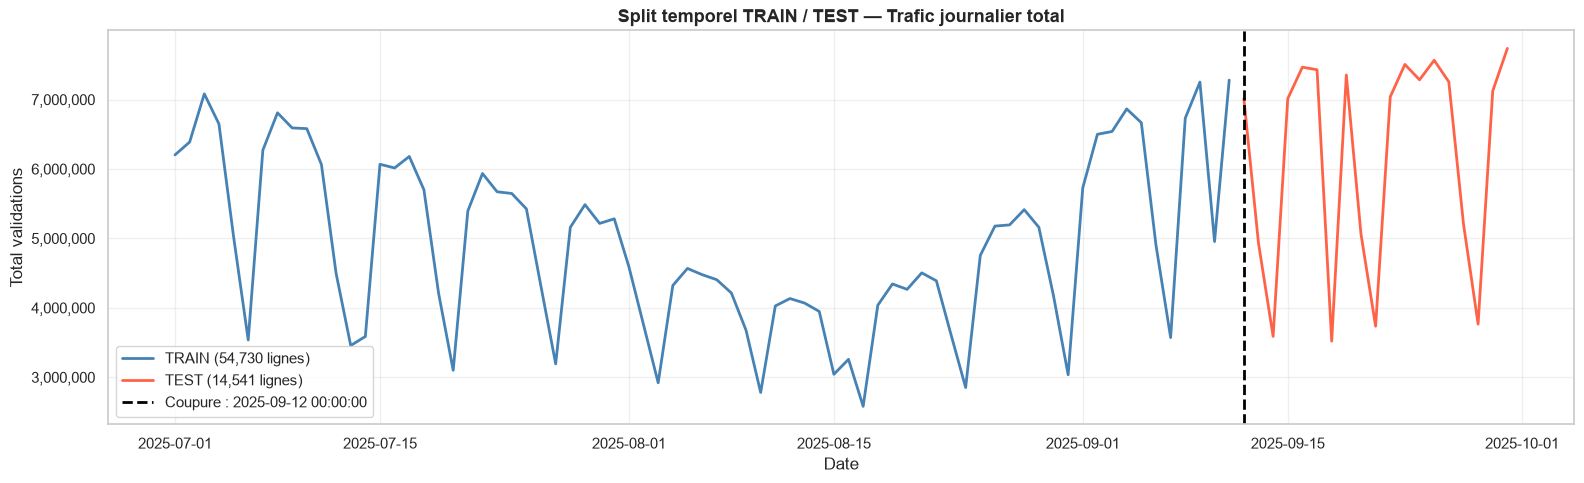

Le TRAIN couvre juillet→mi-septembre (été + début rentrée)
Le TEST couvre la fin septembre (pleine rentrée)
=> Le modèle apprend sur l été et prédit la rentrée — défi réaliste


In [5]:
# Visualisation du split temporel
# POURQUOI CE GRAPHIQUE ?
# Pour vérifier visuellement que le split est correct
# et que le trafic test ressemble au trafic train
# (pas de rupture anormale à la date de coupure)

trafic_train = train.groupby('JOUR')['NB_VALD'].sum().reset_index()
trafic_test  = test.groupby('JOUR')['NB_VALD'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(trafic_train['JOUR'], trafic_train['NB_VALD'],
        color='steelblue', linewidth=2, label=f'TRAIN ({len(train):,} lignes)')
ax.plot(trafic_test['JOUR'], trafic_test['NB_VALD'],
        color='tomato', linewidth=2, label=f'TEST ({len(test):,} lignes)')
ax.axvline(x=pd.to_datetime(date_coupure), color='black',
           linestyle='--', linewidth=2, label=f'Coupure : {date_coupure}')
ax.set_title('Split temporel TRAIN / TEST — Trafic journalier total',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total validations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Le TRAIN couvre juillet→mi-septembre (été + début rentrée)')
print('Le TEST couvre la fin septembre (pleine rentrée)')
print('=> Le modèle apprend sur l été et prédit la rentrée — défi réaliste')

---
## 3. Fonctions utilitaires

### Pourquoi des fonctions ?
On va faire exactement les mêmes analyses pour les 4 modèles.
Au lieu de réécrire le même code 4 fois, on écrit des fonctions
qu'on appelle une fois par modèle — c'est plus propre et plus maintenable.

In [6]:
def compute_metrics(y_true, y_pred, label=''):
    """
    Calcule les 3 métriques de régression.

    RMSE : erreur quadratique moyenne
      - Dans la même unité que NB_VALD (validations)
      - Pénalise plus les grandes erreurs (car on élève au carré)
      - Ex: RMSE=500 => on se trompe en moyenne de 500 validations

    MAE : erreur absolue moyenne
      - Plus robuste aux outliers que RMSE
      - Ex: MAE=300 => erreur typique de 300 validations

    R² : coefficient de détermination
      - Entre 0 et 1 (peut être négatif si le modèle est très mauvais)
      - R²=0.85 => le modèle explique 85% des variations de trafic
      - R²=1.00 => prédiction parfaite (suspect = overfitting)
      - R²=0.00 => le modèle ne fait pas mieux que la moyenne
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'{label} — RMSE: {rmse:,.1f} | MAE: {mae:,.1f} | R²: {r2:.4f}')
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}


def overfitting_status(r2_train, r2_test):
    """
    Détermine si le modèle overfitte, underfitte ou est OK.

    OVERFITTING : le modèle a mémorisé les données d'entraînement
    mais ne généralise pas bien sur de nouvelles données.
    Signe : R² train très élevé, R² test beaucoup plus bas.

    UNDERFITTING : le modèle est trop simple pour capturer
    les patterns dans les données.
    Signe : R² train ET test tous les deux bas.

    OK : le modèle généralise bien.
    Signe : R² train et test proches ET élevés.
    """
    ecart = r2_train - r2_test
    if ecart > OVERFIT_SEUIL:
        return f'OVERFITTING (ecart R²={ecart:.3f} > {OVERFIT_SEUIL})'
    elif r2_test < 0.5:
        return f'UNDERFITTING (R² test={r2_test:.3f} < 0.5)'
    else:
        return f'OK (ecart R²={ecart:.3f})'


def plot_overfitting(metrics_train, metrics_test, model_name):
    """
    Graphique RMSE + R² Train vs Test pour détecter l'overfitting.
    Même structure que le projet diabète (Accuracy + AUC).

    COMMENT LIRE CE GRAPHIQUE :
    - Si les barres Train et Test sont proches → pas d'overfitting
    - Si Train >> Test → overfitting
    - Si les deux sont bas → underfitting
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    categories = ['Train', 'Test']
    colors     = ['steelblue', 'tomato']

    # RMSE
    rmse_vals = [metrics_train['RMSE'], metrics_test['RMSE']]
    axes[0].bar(categories, rmse_vals, color=colors, edgecolor='white', width=0.5)
    axes[0].set_title('RMSE Train vs Test\n(plus bas = meilleur)')
    axes[0].set_ylabel('RMSE (validations)')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    for i, v in enumerate(rmse_vals):
        axes[0].text(i, v + v*0.02, f'{v:,.0f}', ha='center', fontweight='bold')

    # R²
    r2_vals = [metrics_train['R2'], metrics_test['R2']]
    bars = axes[1].bar(categories, r2_vals, color=colors, edgecolor='white', width=0.5)
    axes[1].set_ylim(0, 1.15)
    axes[1].set_title('R² Train vs Test\n(plus haut = meilleur, objectif > 0.85)')
    axes[1].set_ylabel('R²')
    axes[1].axhline(R2_OBJECTIF, color='green', linestyle='--',
                    linewidth=1.5, label=f'Objectif R²={R2_OBJECTIF}')
    axes[1].axhline(OVERFIT_SEUIL, color='gray', linestyle=':', linewidth=1)
    axes[1].legend()
    for i, v in enumerate(r2_vals):
        axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

    statut = overfitting_status(metrics_train['R2'], metrics_test['R2'])
    plt.suptitle(f'{model_name} — Overfitting / Underfitting\nStatut : {statut}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_predictions_vs_real(y_test, y_pred, model_name):
    """
    Graphique Valeurs réelles vs Valeurs prédites.

    COMMENT LIRE CE GRAPHIQUE :
    - Chaque point = une prédiction
    - La ligne diagonale = prédiction parfaite
    - Plus les points sont proches de la diagonale → meilleur le modèle
    - Les points loin de la diagonale = erreurs importantes
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Scatter plot réel vs prédit
    axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
    lim = max(y_test.max(), y_pred.max())
    axes[0].plot([0, lim], [0, lim], 'r--', linewidth=2, label='Prédiction parfaite')
    axes[0].set_xlabel('Valeurs réelles (NB_VALD)')
    axes[0].set_ylabel('Valeurs prédites')
    axes[0].set_title('Réel vs Prédit\n(points sur la diagonale = parfait)')
    axes[0].legend()
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

    # Distribution des résidus
    # RÉSIDU = valeur réelle - valeur prédite
    # Un bon modèle a des résidus centrés sur 0 et en forme de cloche
    # Des résidus biaisés (pas centrés sur 0) → le modèle se trompe systématiquement
    residus = np.array(y_test) - np.array(y_pred)
    axes[1].hist(residus, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur = 0 (parfait)')
    axes[1].axvline(residus.mean(), color='orange', linestyle='--',
                    linewidth=2, label=f'Moyenne résidus = {residus.mean():,.0f}')
    axes[1].set_xlabel('Résidu (réel - prédit)')
    axes[1].set_ylabel('Nombre de prédictions')
    axes[1].set_title('Distribution des résidus\n(centré sur 0 = bon signe)')
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

    plt.suptitle(f'{model_name} — Qualité des prédictions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_predictions_timeline(test_df, y_pred, model_name, arret='CHATELET'):
    """
    Évolution temporelle des prédictions vs réalité pour un arrêt.

    COMMENT LIRE CE GRAPHIQUE :
    - Ligne bleue = trafic réel
    - Ligne rouge = trafic prédit
    - Si les deux lignes se superposent bien → modèle précis
    - On regarde un arrêt connu (CHATELET) pour interpréter facilement
    """
    df_plot = test_df.copy()
    df_plot['y_pred'] = y_pred
    df_arret = df_plot[df_plot['LIBELLE_ARRET'] == arret].sort_values('JOUR')

    if len(df_arret) == 0:
        print(f'Arrêt {arret} non trouvé dans le test set')
        return

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(df_arret['JOUR'], df_arret[TARGET],
            color='steelblue', linewidth=2, marker='o', markersize=4, label='Réel')
    ax.plot(df_arret['JOUR'], df_arret['y_pred'],
            color='tomato', linewidth=2, marker='s', markersize=4,
            linestyle='--', label='Prédit')
    ax.fill_between(df_arret['JOUR'],
                    df_arret[TARGET], df_arret['y_pred'],
                    alpha=0.2, color='orange', label='Écart')
    ax.set_title(f'{model_name} — Prédictions vs Réel pour {arret}\n'
                 f'(période test)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('NB_VALD')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, model_name, top_n=12):
    """
    Importance des features — quelles variables influencent le plus le modèle ?

    COMMENT LIRE CE GRAPHIQUE :
    - Plus la barre est longue → plus la feature est importante
    - On s'attend à ce que lag7 et rolling_mean_7j soient en tête
    - is_weekend devrait aussi être important

    DISPONIBLE UNIQUEMENT pour Decision Tree, Random Forest, XGBoost
    (pas pour la régression linéaire)
    """
    if not hasattr(model, 'feature_importances_'):
        print(f'{model_name} : pas de feature_importances_ disponible')
        return

    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.nlargest(top_n).sort_values()

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['tomato' if v == importances.max() else 'steelblue'
              for v in importances.values]
    bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
    ax.set_xlabel('Importance (contribution au modèle)')
    ax.set_title(f'{model_name} — Importance des features\n'
                 f'(rouge = feature la plus importante)', fontsize=12, fontweight='bold')
    for bar, val in zip(bars, importances.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f'\nTop 3 features les plus importantes pour {model_name} :')
    for i, (feat, imp) in enumerate(importances.nlargest(3).items(), 1):
        print(f'  {i}. {feat} : {imp:.3f}')


print('Fonctions utilitaires chargées.')

Fonctions utilitaires chargées.


---
## 4. Définition et entraînement des 4 modèles

### Pourquoi ces hyperparamètres ?

**Régression Linéaire** : aucun hyperparamètre — c'est le modèle le plus simple possible.
Il suppose une relation linéaire entre les features et NB_VALD.

**Decision Tree** : `max_depth=10` pour limiter l'overfitting.
Sans limite, l'arbre mémoriserait chaque ligne du train.

**Random Forest** : `n_estimators=100` = 100 arbres.
La moyenne de 100 arbres est beaucoup plus stable qu'un seul arbre.

**XGBoost** : `n_estimators=300`, `learning_rate=0.05`, `max_depth=6`.
Il construit les arbres séquentiellement — chaque arbre corrige les erreurs du précédent.

In [7]:
models = {
    'LinearRegression': LinearRegression(),

    'DecisionTree': DecisionTreeRegressor(
        max_depth=10,        # profondeur max = évite la mémorisation
        min_samples_leaf=5,  # minimum 5 exemples par feuille
        random_state=42
    ),

    'RandomForest': RandomForestRegressor(
        n_estimators=100,    # 100 arbres
        max_depth=15,        # profondeur max par arbre
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1            # utiliser tous les coeurs CPU
    ),

    'XGBoost': XGBRegressor(
        n_estimators=300,    # 300 arbres boostés
        learning_rate=0.05,  # pas d'apprentissage (petit = plus précis mais plus lent)
        max_depth=6,         # profondeur max
        subsample=0.8,       # 80% des données par arbre (régularisation)
        colsample_bytree=0.8,# 80% des features par arbre (régularisation)
        random_state=42,
        n_jobs=-1
    )
}

# Entraînement
print('Entraînement des modèles...')
print('=' * 45)
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'✅ {name} entraîné')
print('=' * 45)
print('Tous les modèles sont entraînés.')

Entraînement des modèles...
✅ LinearRegression entraîné
✅ DecisionTree entraîné
✅ RandomForest entraîné
✅ XGBoost entraîné
Tous les modèles sont entraînés.


---
## MODÈLE 1 : Régression Linéaire (Baseline)

### Pourquoi commencer par la régression linéaire ?
C'est notre **baseline** — le modèle le plus simple.
Si XGBoost ne fait pas mieux que ça, il y a un problème.
La régression linéaire suppose que NB_VALD est une combinaison
linéaire des features : `NB_VALD = a×lag7 + b×is_weekend + c×mois + ...`
C'est une hypothèse trop simpliste pour notre problème.

In [8]:
MODEL_NAME = 'LinearRegression'
model_lr   = models[MODEL_NAME]

y_pred_train_lr = model_lr.predict(X_train)
y_pred_test_lr  = model_lr.predict(X_test)

metrics_train_lr = compute_metrics(y_train, y_pred_train_lr)
metrics_test_lr  = compute_metrics(y_test,  y_pred_test_lr)

print('=' * 55)
print('RÉGRESSION LINÉAIRE — Overfitting/Underfitting')
print('=' * 55)
print(f'RMSE  : Train={metrics_train_lr["RMSE"]:>10,.1f} | Test={metrics_test_lr["RMSE"]:>10,.1f}')
print(f'MAE   : Train={metrics_train_lr["MAE"]:>10,.1f} | Test={metrics_test_lr["MAE"]:>10,.1f}')
print(f'R²    : Train={metrics_train_lr["R2"]:>10.4f} | Test={metrics_test_lr["R2"]:>10.4f}')
print(f'Statut: {overfitting_status(metrics_train_lr["R2"], metrics_test_lr["R2"])}')

RÉGRESSION LINÉAIRE — Overfitting/Underfitting
RMSE  : Train=   2,344.2 | Test=   3,229.1
MAE   : Train=   1,022.6 | Test=   1,520.5
R²    : Train=    0.9683 | Test=    0.9536
Statut: OK (ecart R²=0.015)


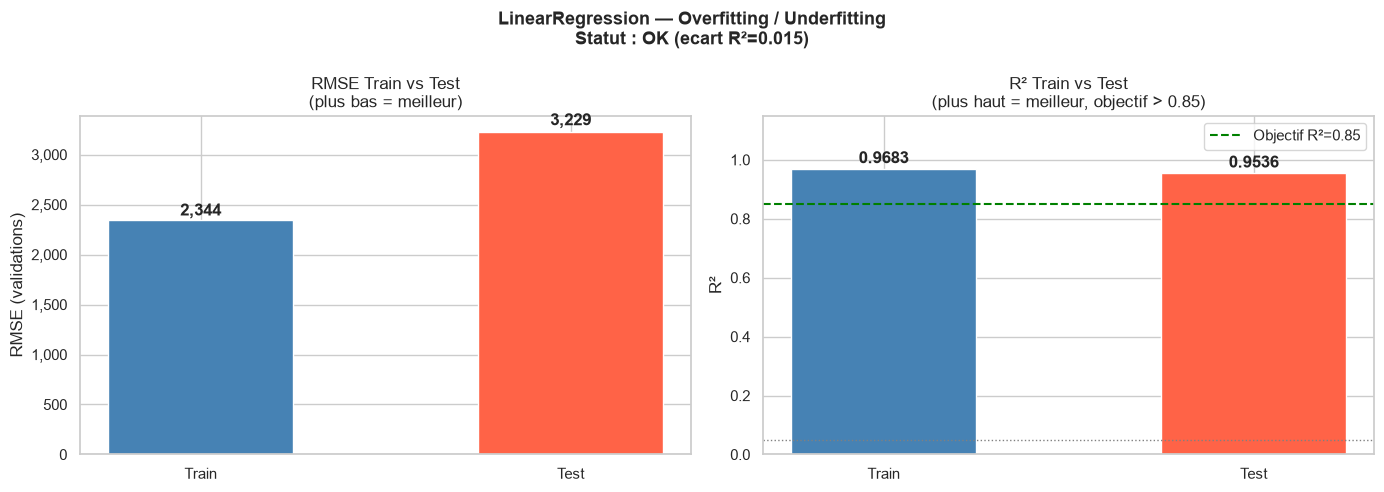

In [9]:
# Graphique overfitting
plot_overfitting(metrics_train_lr, metrics_test_lr, MODEL_NAME)

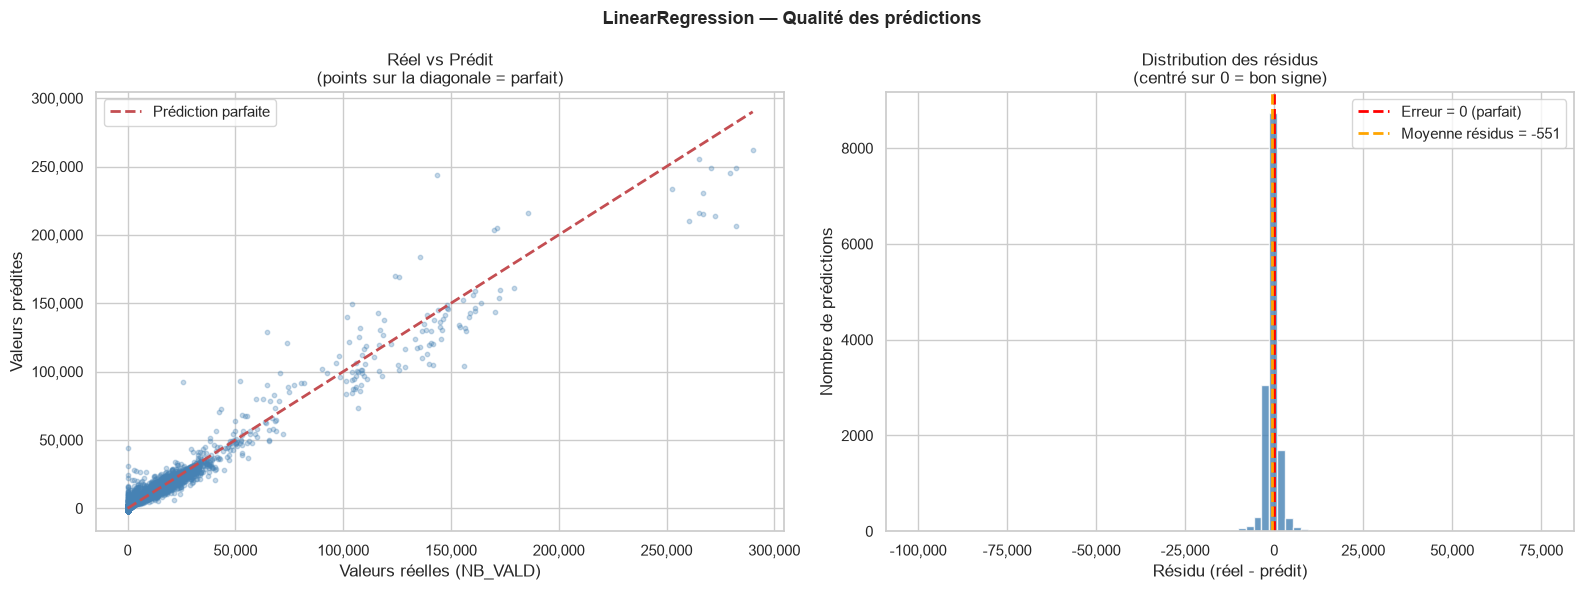

In [10]:
# Réel vs Prédit + Résidus
plot_predictions_vs_real(y_test, y_pred_test_lr, MODEL_NAME)

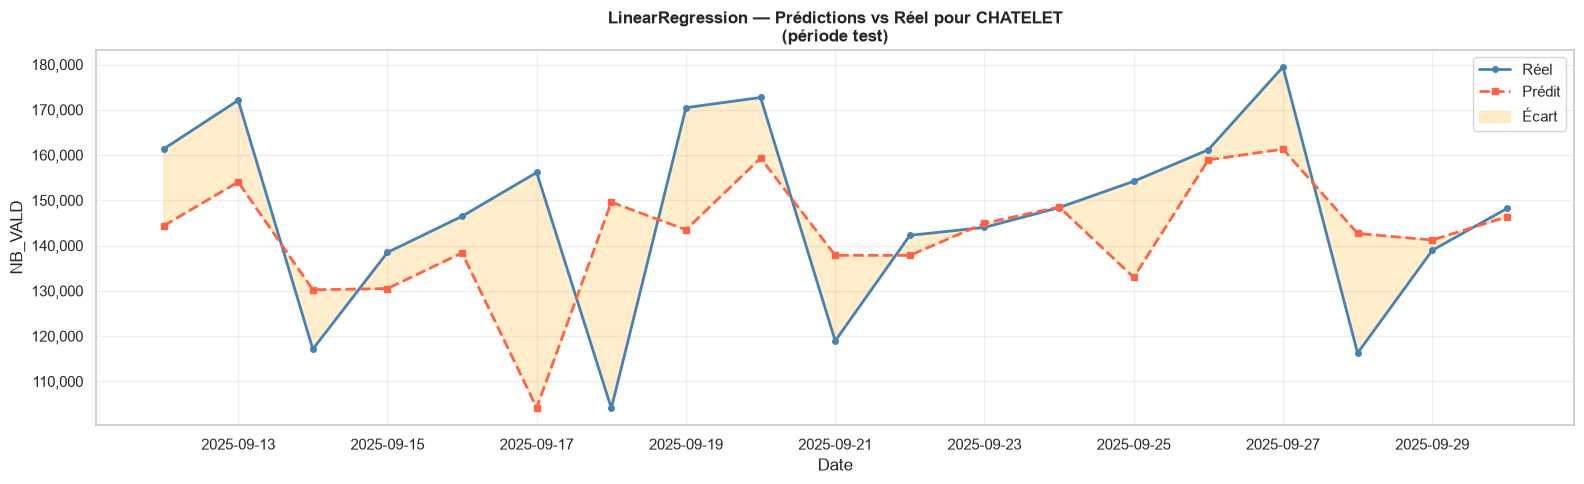

In [11]:
# Timeline pour CHATELET
plot_predictions_timeline(test, y_pred_test_lr, MODEL_NAME, arret='CHATELET')

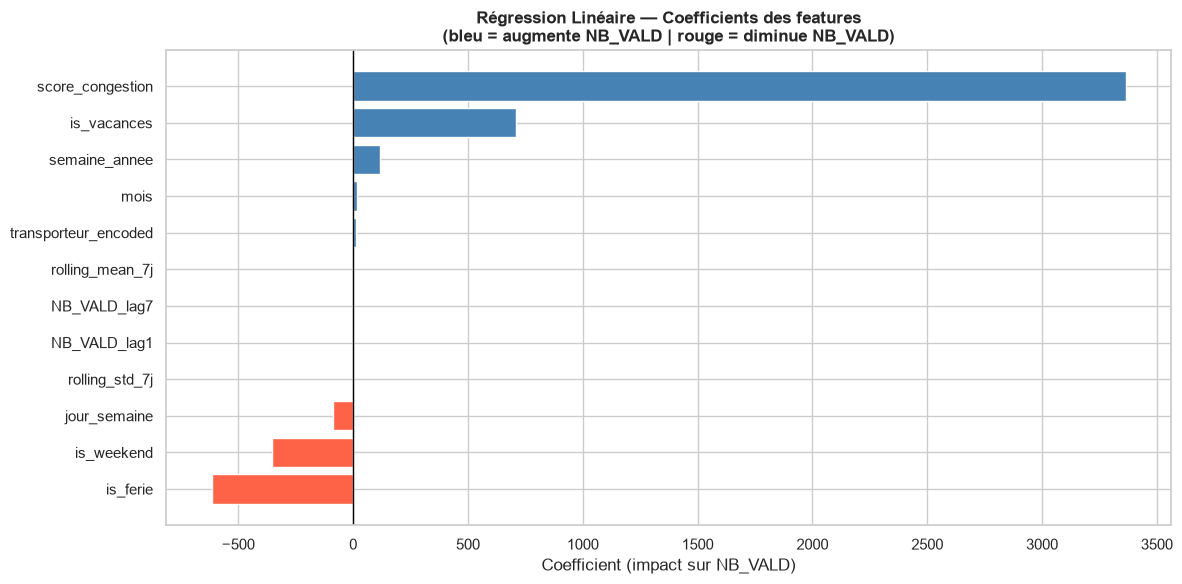

In [12]:
# Coefficients de la régression linéaire
# POURQUOI : les coefficients montrent l'impact de chaque feature
# Un coefficient positif = augmente NB_VALD
# Un coefficient négatif = diminue NB_VALD
coefs = pd.Series(model_lr.coef_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['tomato' if v < 0 else 'steelblue' for v in coefs.values]
ax.barh(coefs.index, coefs.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coefficient (impact sur NB_VALD)')
ax.set_title('Régression Linéaire — Coefficients des features\n'
             '(bleu = augmente NB_VALD | rouge = diminue NB_VALD)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## MODÈLE 2 : Decision Tree

### Pourquoi un Decision Tree ?
Un arbre de décision découpe les données en posant des questions successives.
Ex : `lag7 > 5000 ?` → si oui → `is_weekend = True ?` → ...
C'est interprétable mais sujet à l'overfitting si trop profond.
C'est la brique de base de Random Forest et XGBoost.

In [13]:
MODEL_NAME = 'DecisionTree'
model_dt   = models[MODEL_NAME]

y_pred_train_dt = model_dt.predict(X_train)
y_pred_test_dt  = model_dt.predict(X_test)

metrics_train_dt = compute_metrics(y_train, y_pred_train_dt)
metrics_test_dt  = compute_metrics(y_test,  y_pred_test_dt)

print('=' * 55)
print('DECISION TREE — Overfitting/Underfitting')
print('=' * 55)
print(f'RMSE  : Train={metrics_train_dt["RMSE"]:>10,.1f} | Test={metrics_test_dt["RMSE"]:>10,.1f}')
print(f'MAE   : Train={metrics_train_dt["MAE"]:>10,.1f} | Test={metrics_test_dt["MAE"]:>10,.1f}')
print(f'R²    : Train={metrics_train_dt["R2"]:>10.4f} | Test={metrics_test_dt["R2"]:>10.4f}')
print(f'Statut: {overfitting_status(metrics_train_dt["R2"], metrics_test_dt["R2"])}')

DECISION TREE — Overfitting/Underfitting
RMSE  : Train=   1,173.5 | Test=   2,729.6
MAE   : Train=     529.4 | Test=     952.0
R²    : Train=    0.9921 | Test=    0.9668
Statut: OK (ecart R²=0.025)


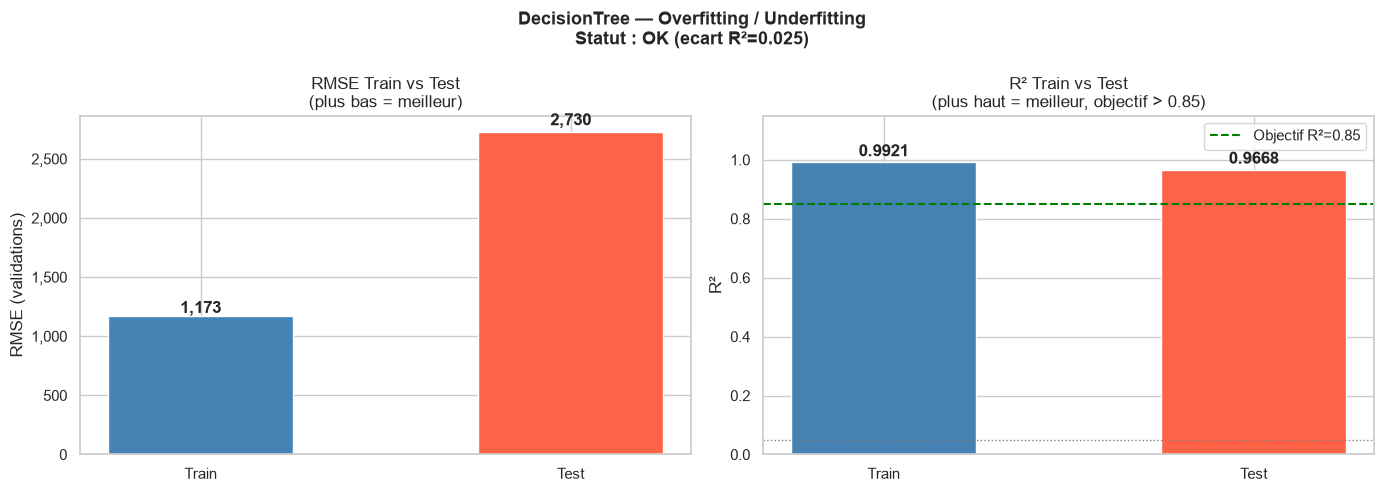

In [14]:
plot_overfitting(metrics_train_dt, metrics_test_dt, MODEL_NAME)

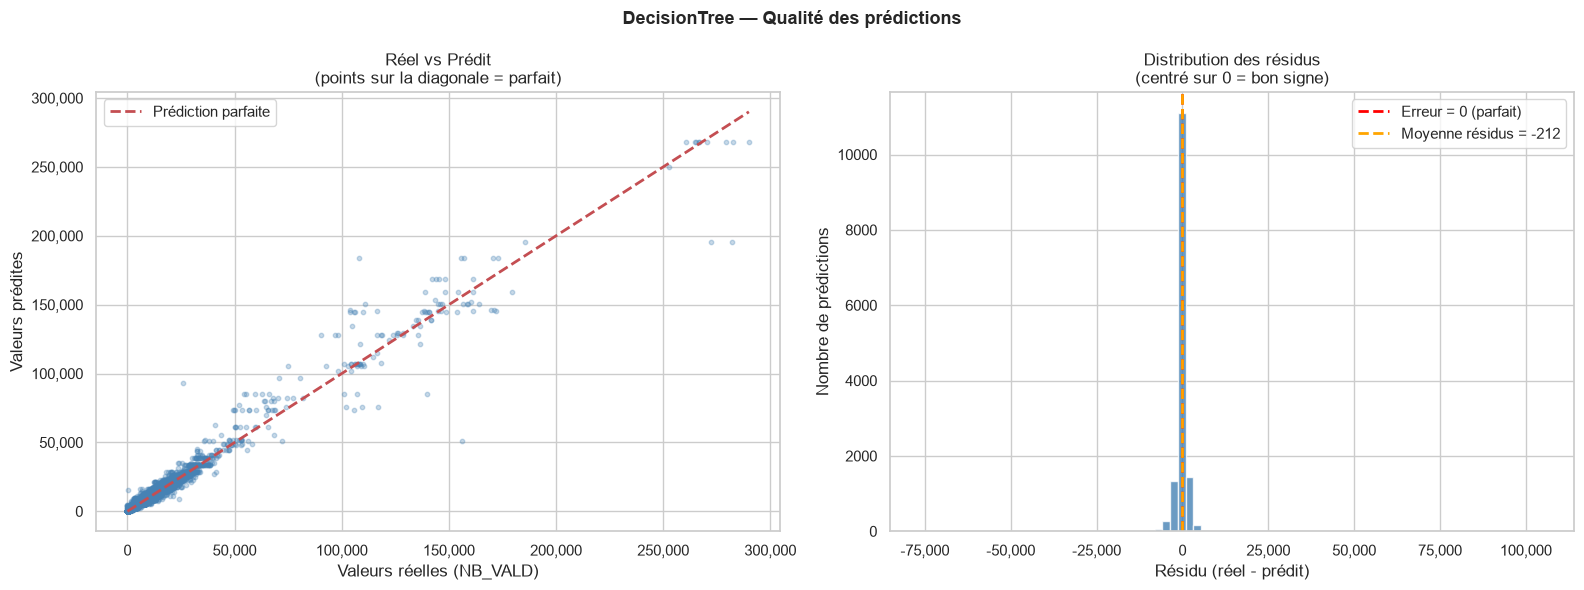

In [15]:
plot_predictions_vs_real(y_test, y_pred_test_dt, MODEL_NAME)

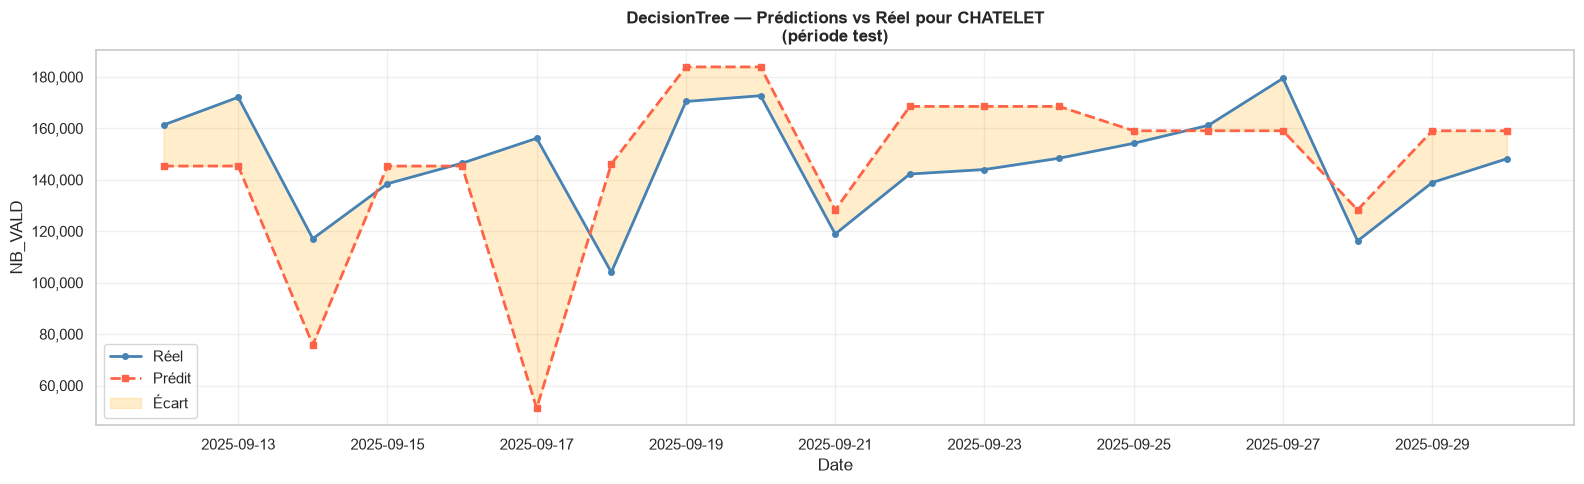

In [16]:
plot_predictions_timeline(test, y_pred_test_dt, MODEL_NAME, arret='CHATELET')

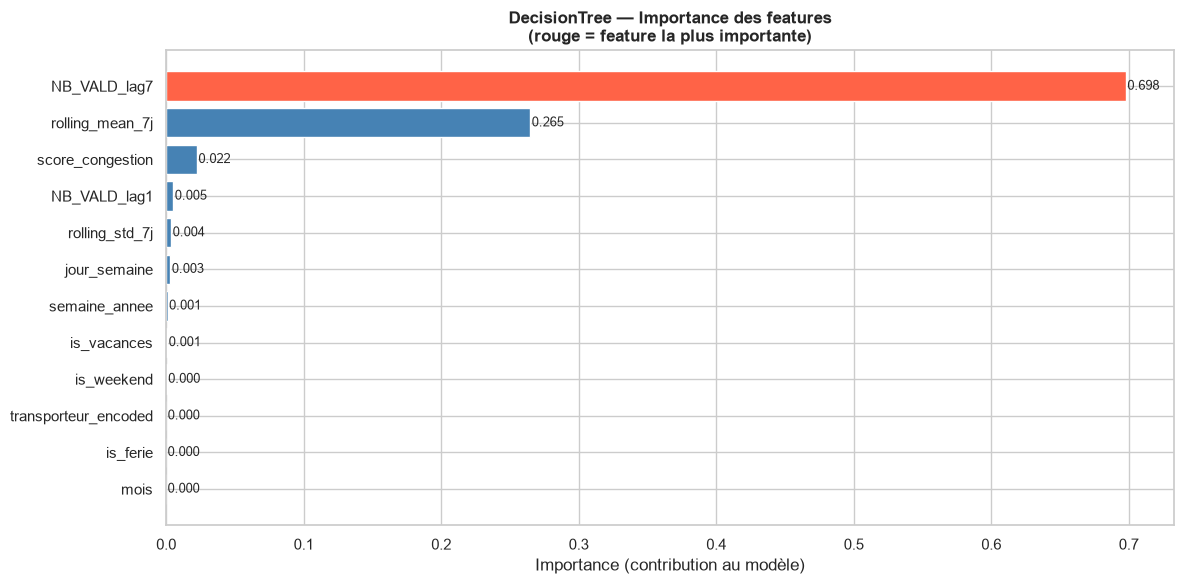


Top 3 features les plus importantes pour DecisionTree :
  1. NB_VALD_lag7 : 0.698
  2. rolling_mean_7j : 0.265
  3. score_congestion : 0.022


In [17]:
plot_feature_importance(model_dt, FEATURES, MODEL_NAME)

---
## MODÈLE 3 : Random Forest

### Pourquoi Random Forest est meilleur qu'un seul Decision Tree ?
Random Forest entraîne **100 arbres indépendants** et fait la moyenne de leurs prédictions.
Chaque arbre voit un sous-ensemble aléatoire des données et des features.
La moyenne de 100 arbres est beaucoup plus stable et précise qu'un seul arbre.
C'est le principe de la **sagesse des foules** — 100 avis valent mieux qu'un.

In [18]:
MODEL_NAME = 'RandomForest'
model_rf   = models[MODEL_NAME]

y_pred_train_rf = model_rf.predict(X_train)
y_pred_test_rf  = model_rf.predict(X_test)

metrics_train_rf = compute_metrics(y_train, y_pred_train_rf)
metrics_test_rf  = compute_metrics(y_test,  y_pred_test_rf)

print('=' * 55)
print('RANDOM FOREST — Overfitting/Underfitting')
print('=' * 55)
print(f'RMSE  : Train={metrics_train_rf["RMSE"]:>10,.1f} | Test={metrics_test_rf["RMSE"]:>10,.1f}')
print(f'MAE   : Train={metrics_train_rf["MAE"]:>10,.1f} | Test={metrics_test_rf["MAE"]:>10,.1f}')
print(f'R²    : Train={metrics_train_rf["R2"]:>10.4f} | Test={metrics_test_rf["R2"]:>10.4f}')
print(f'Statut: {overfitting_status(metrics_train_rf["R2"], metrics_test_rf["R2"])}')

RANDOM FOREST — Overfitting/Underfitting
RMSE  : Train=     718.5 | Test=   1,857.2
MAE   : Train=     246.0 | Test=     651.2
R²    : Train=    0.9970 | Test=    0.9847
Statut: OK (ecart R²=0.012)


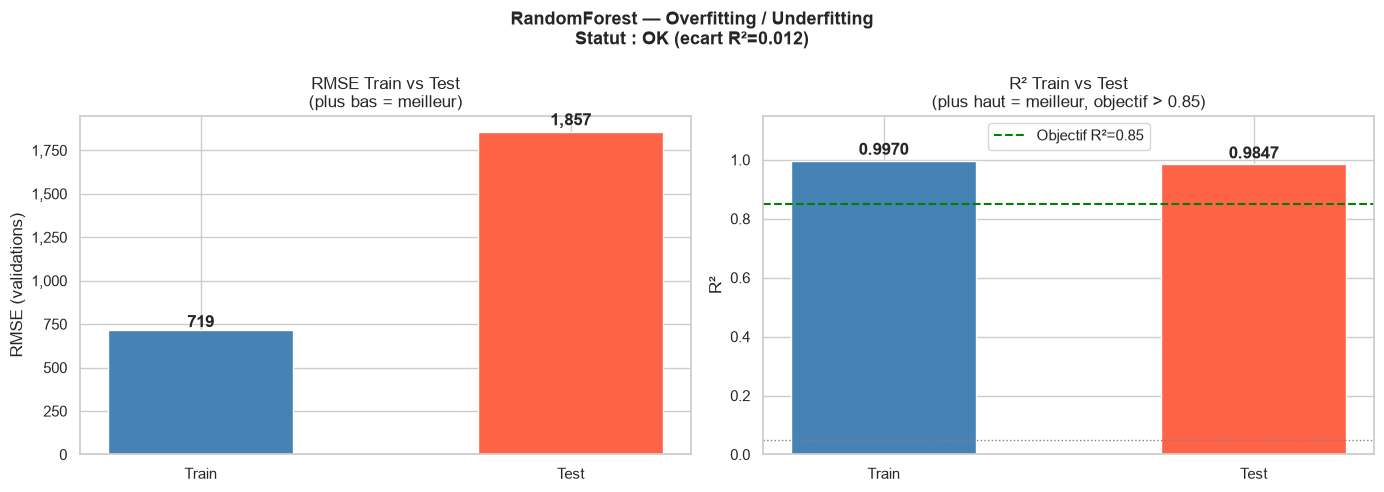

In [19]:
plot_overfitting(metrics_train_rf, metrics_test_rf, MODEL_NAME)

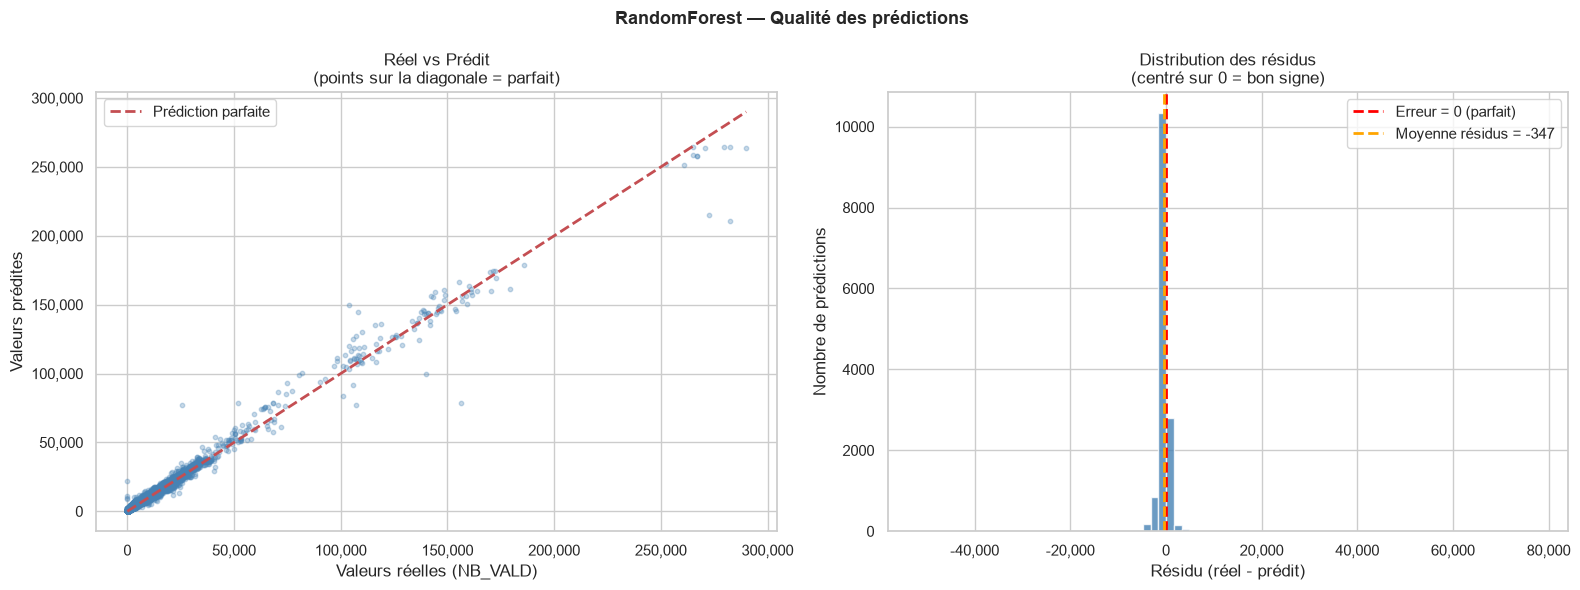

In [20]:
plot_predictions_vs_real(y_test, y_pred_test_rf, MODEL_NAME)

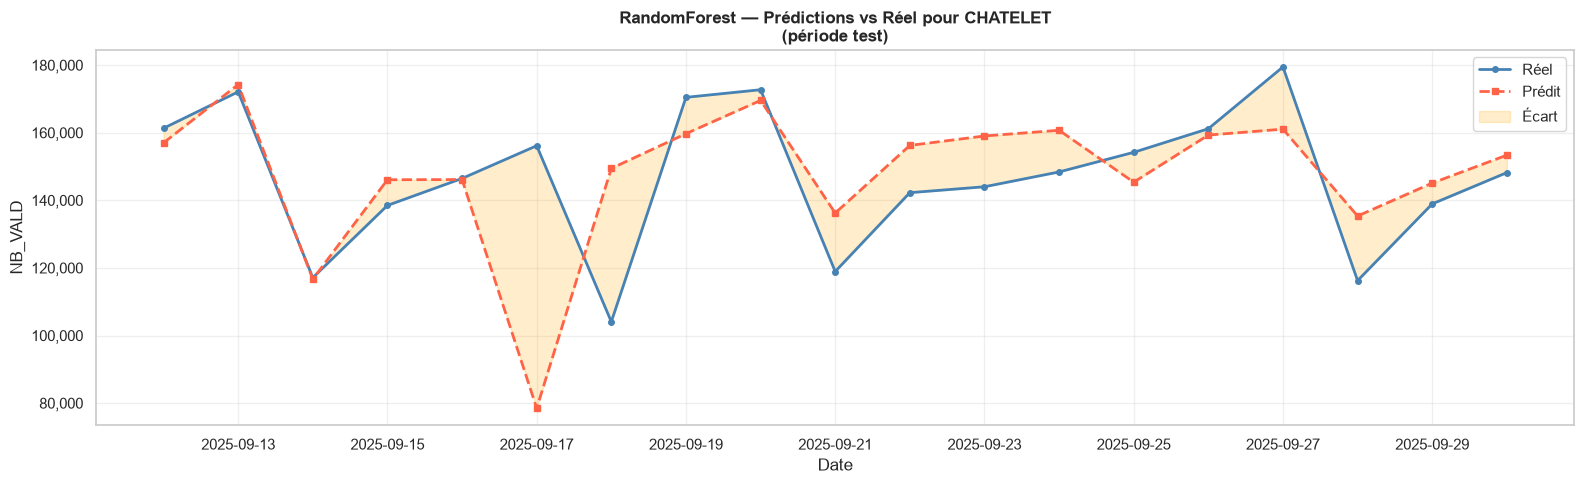

In [21]:
plot_predictions_timeline(test, y_pred_test_rf, MODEL_NAME, arret='CHATELET')

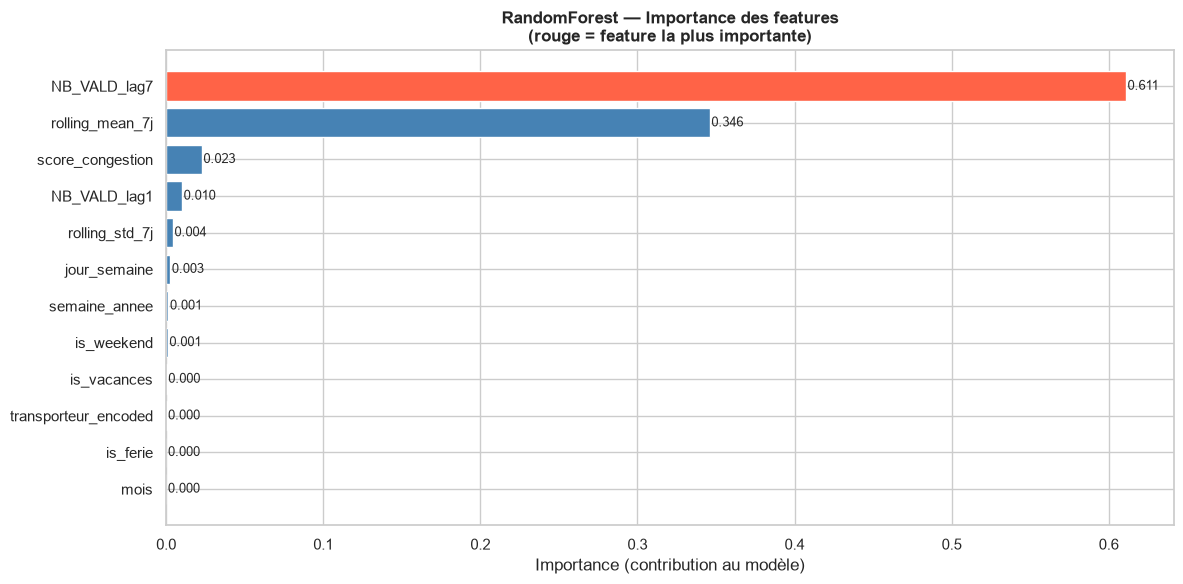


Top 3 features les plus importantes pour RandomForest :
  1. NB_VALD_lag7 : 0.611
  2. rolling_mean_7j : 0.346
  3. score_congestion : 0.023


In [22]:
plot_feature_importance(model_rf, FEATURES, MODEL_NAME)

---
## MODÈLE 4 : XGBoost

### Pourquoi XGBoost est le champion attendu ?
Contrairement à Random Forest qui construit les arbres en **parallèle**,
XGBoost les construit en **séquence** — chaque arbre corrige les erreurs du précédent.
C'est le **gradient boosting** — on descend le gradient de la fonction de perte.
Sur les données tabulaires (tableaux), XGBoost est presque toujours le meilleur.

In [23]:
MODEL_NAME = 'XGBoost'
model_xgb  = models[MODEL_NAME]

y_pred_train_xgb = model_xgb.predict(X_train)
y_pred_test_xgb  = model_xgb.predict(X_test)

metrics_train_xgb = compute_metrics(y_train, y_pred_train_xgb)
metrics_test_xgb  = compute_metrics(y_test,  y_pred_test_xgb)

print('=' * 55)
print('XGBOOST — Overfitting/Underfitting')
print('=' * 55)
print(f'RMSE  : Train={metrics_train_xgb["RMSE"]:>10,.1f} | Test={metrics_test_xgb["RMSE"]:>10,.1f}')
print(f'MAE   : Train={metrics_train_xgb["MAE"]:>10,.1f} | Test={metrics_test_xgb["MAE"]:>10,.1f}')
print(f'R²    : Train={metrics_train_xgb["R2"]:>10.4f} | Test={metrics_test_xgb["R2"]:>10.4f}')
print(f'Statut: {overfitting_status(metrics_train_xgb["R2"], metrics_test_xgb["R2"])}')

XGBOOST — Overfitting/Underfitting
RMSE  : Train=     746.3 | Test=   3,381.4
MAE   : Train=     344.6 | Test=     807.1
R²    : Train=    0.9968 | Test=    0.9491
Statut: OK (ecart R²=0.048)


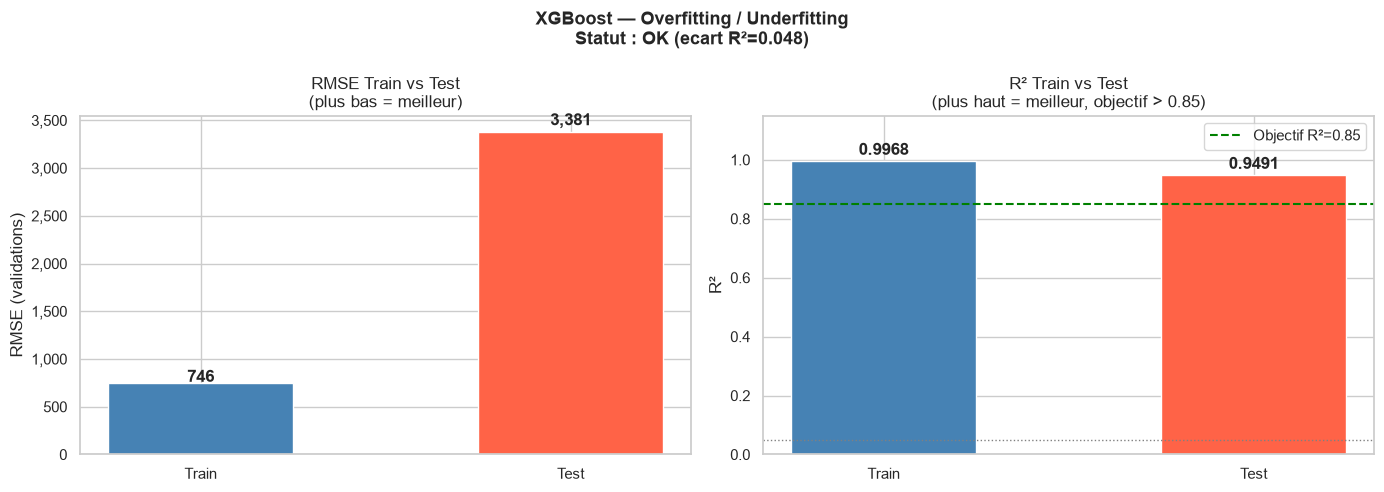

In [24]:
plot_overfitting(metrics_train_xgb, metrics_test_xgb, MODEL_NAME)

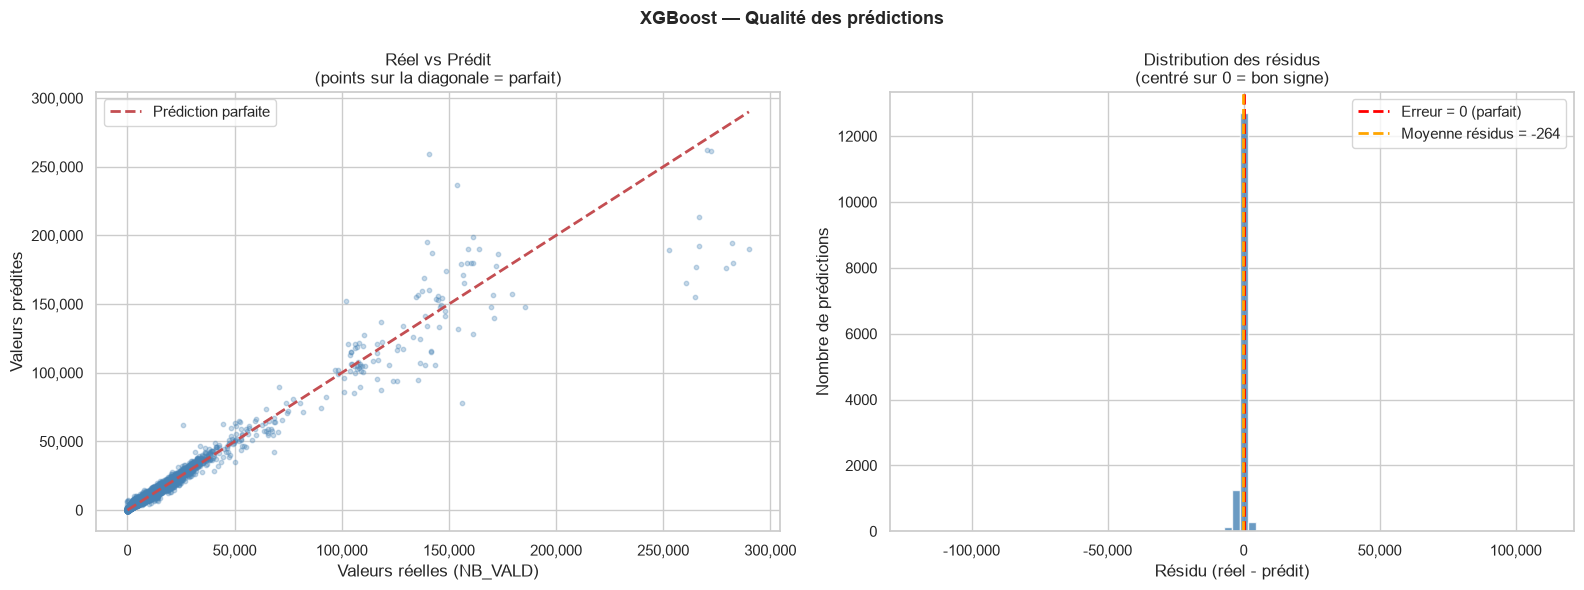

In [25]:
plot_predictions_vs_real(y_test, y_pred_test_xgb, MODEL_NAME)

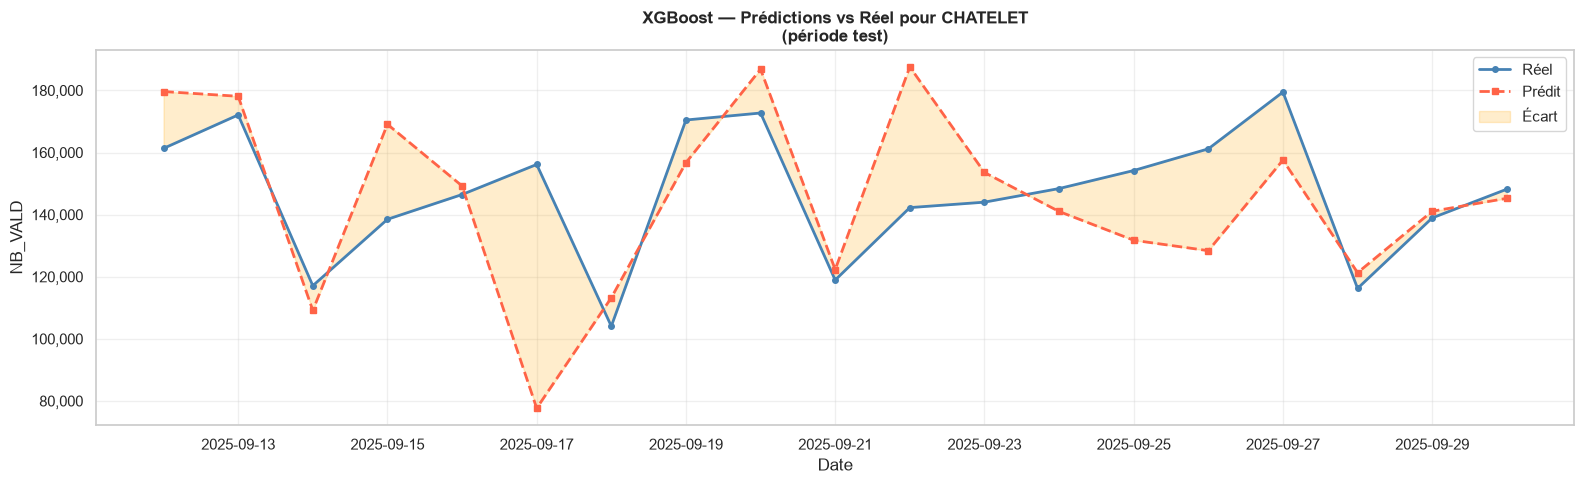

In [26]:
plot_predictions_timeline(test, y_pred_test_xgb, MODEL_NAME, arret='CHATELET')

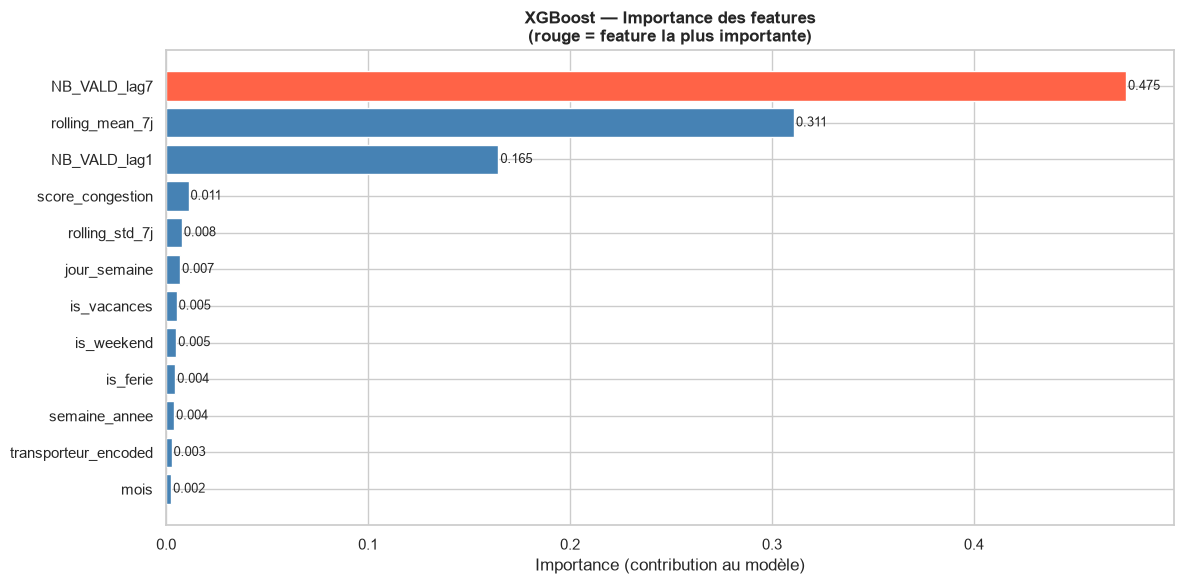


Top 3 features les plus importantes pour XGBoost :
  1. NB_VALD_lag7 : 0.475
  2. rolling_mean_7j : 0.311
  3. NB_VALD_lag1 : 0.165


In [27]:
plot_feature_importance(model_xgb, FEATURES, MODEL_NAME)

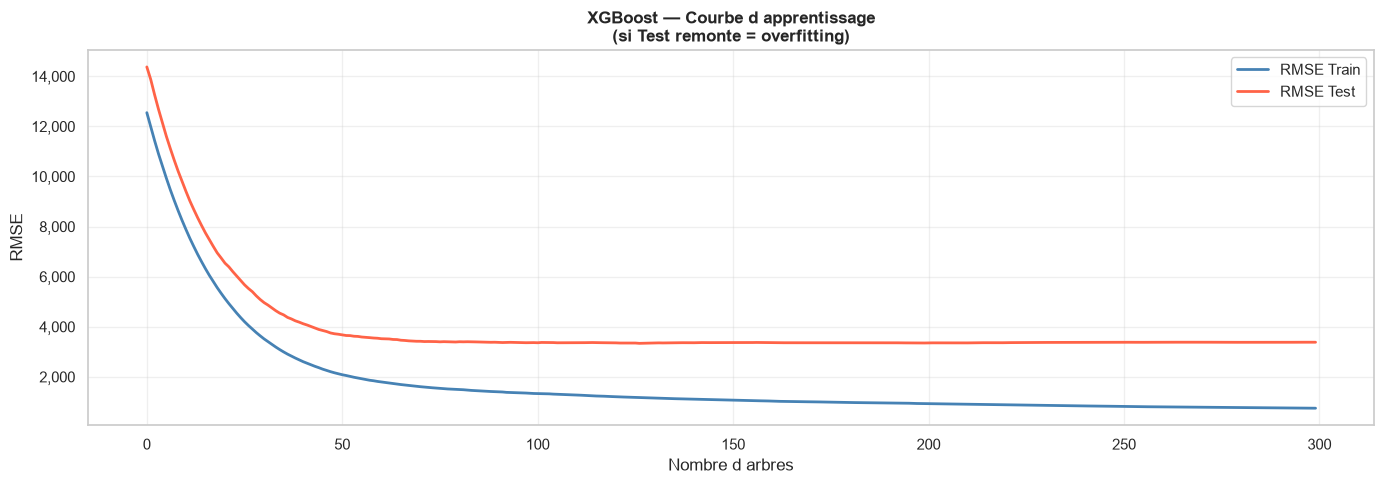

In [28]:
# Courbe d'apprentissage XGBoost
# POURQUOI CE GRAPHIQUE ?
# Elle montre comment l'erreur évolue au fur et à mesure
# qu'on ajoute des arbres (de 1 à 300).
# Si l'erreur train continue à baisser mais l'erreur test remonte
# → overfitting à partir de ce nombre d'arbres

results = {}
model_xgb_curve = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
model_xgb_curve.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
results = model_xgb_curve.evals_result()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(results['validation_0']['rmse'], label='RMSE Train', color='steelblue', linewidth=2)
ax.plot(results['validation_1']['rmse'], label='RMSE Test',  color='tomato',    linewidth=2)
ax.set_xlabel('Nombre d arbres')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost — Courbe d apprentissage\n'
             '(si Test remonte = overfitting)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Comparaison finale des 4 modèles

### Critères de sélection
On choisit le meilleur modèle selon :
1. **R² test > 0.85** — objectif minimum
2. **RMSE test minimum** — erreur la plus faible
3. **Pas d'overfitting** — écart R² train/test < 0.05
4. **MAE test minimum** — erreur typique la plus faible

In [29]:
# Tableau comparatif
resultats = pd.DataFrame([
    {
        'Modèle'      : 'LinearRegression',
        'RMSE_train'  : metrics_train_lr['RMSE'],
        'RMSE_test'   : metrics_test_lr['RMSE'],
        'MAE_test'    : metrics_test_lr['MAE'],
        'R2_train'    : metrics_train_lr['R2'],
        'R2_test'     : metrics_test_lr['R2'],
        'Ecart_R2'    : metrics_train_lr['R2'] - metrics_test_lr['R2'],
        'Statut'      : overfitting_status(metrics_train_lr['R2'], metrics_test_lr['R2'])
    },
    {
        'Modèle'      : 'DecisionTree',
        'RMSE_train'  : metrics_train_dt['RMSE'],
        'RMSE_test'   : metrics_test_dt['RMSE'],
        'MAE_test'    : metrics_test_dt['MAE'],
        'R2_train'    : metrics_train_dt['R2'],
        'R2_test'     : metrics_test_dt['R2'],
        'Ecart_R2'    : metrics_train_dt['R2'] - metrics_test_dt['R2'],
        'Statut'      : overfitting_status(metrics_train_dt['R2'], metrics_test_dt['R2'])
    },
    {
        'Modèle'      : 'RandomForest',
        'RMSE_train'  : metrics_train_rf['RMSE'],
        'RMSE_test'   : metrics_test_rf['RMSE'],
        'MAE_test'    : metrics_test_rf['MAE'],
        'R2_train'    : metrics_train_rf['R2'],
        'R2_test'     : metrics_test_rf['R2'],
        'Ecart_R2'    : metrics_train_rf['R2'] - metrics_test_rf['R2'],
        'Statut'      : overfitting_status(metrics_train_rf['R2'], metrics_test_rf['R2'])
    },
    {
        'Modèle'      : 'XGBoost',
        'RMSE_train'  : metrics_train_xgb['RMSE'],
        'RMSE_test'   : metrics_test_xgb['RMSE'],
        'MAE_test'    : metrics_test_xgb['MAE'],
        'R2_train'    : metrics_train_xgb['R2'],
        'R2_test'     : metrics_test_xgb['R2'],
        'Ecart_R2'    : metrics_train_xgb['R2'] - metrics_test_xgb['R2'],
        'Statut'      : overfitting_status(metrics_train_xgb['R2'], metrics_test_xgb['R2'])
    }
])

# Formater pour l'affichage
resultats_display = resultats.copy()
for col in ['RMSE_train','RMSE_test','MAE_test']:
    resultats_display[col] = resultats_display[col].apply(lambda x: f'{x:,.0f}')
for col in ['R2_train','R2_test','Ecart_R2']:
    resultats_display[col] = resultats_display[col].apply(lambda x: f'{x:.4f}')

print('=' * 80)
print('COMPARAISON FINALE DES 4 MODÈLES')
print('=' * 80)
display(resultats_display)

# Meilleur modèle = R² test max sans overfitting
ok_models = resultats[resultats['Statut'].str.startswith('OK')]
if len(ok_models) > 0:
    best = ok_models.loc[ok_models['R2_test'].idxmax()]
    print(f'\nMeilleur modèle : {best["Modèle"]}')
    print(f'  R² test  = {best["R2_test"]:.4f}')
    print(f'  RMSE test = {best["RMSE_test"]:,.0f} validations')
    print(f'  Statut   = {best["Statut"]}')

COMPARAISON FINALE DES 4 MODÈLES


,Modèle,RMSE_train,RMSE_test,MAE_test,R2_train,R2_test,Ecart_R2,Statut
0,LinearRegression,"2,344","3,229","1,520",0.9683,0.9536,0.0147,OK (ecart R²=0.015)
1,DecisionTree,"1,173","2,730",952,0.9921,0.9668,0.0252,OK (ecart R²=0.025)
2,RandomForest,719,"1,857",651,0.9970,0.9847,0.0124,OK (ecart R²=0.012)
3,XGBoost,746,"3,381",807,0.9968,0.9491,0.0477,OK (ecart R²=0.048)



Meilleur modèle : RandomForest
  R² test  = 0.9847
  RMSE test = 1,857 validations
  Statut   = OK (ecart R²=0.012)


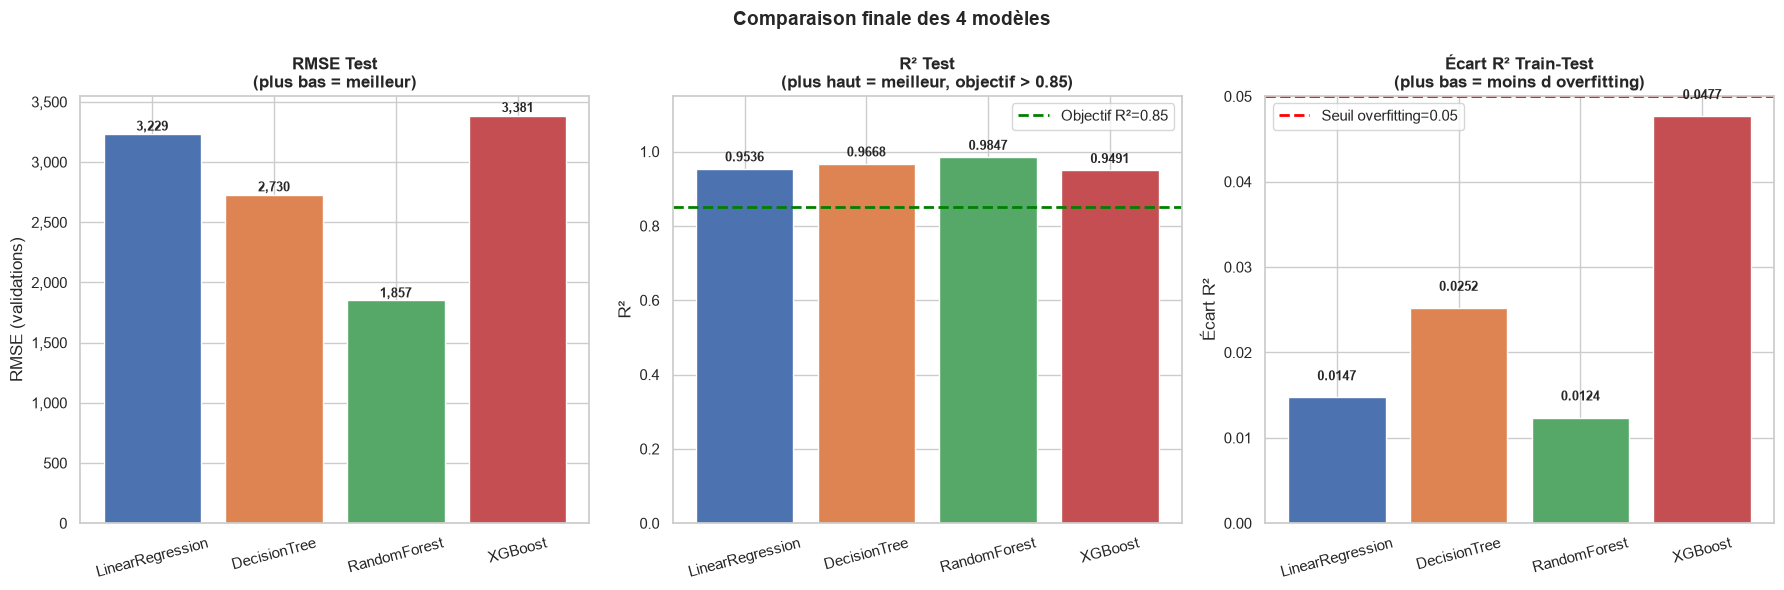

In [30]:
# Graphique comparatif — même structure que le projet diabète
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
modeles   = resultats['Modèle'].tolist()
couleurs  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# RMSE Test
bars0 = axes[0].bar(modeles, resultats['RMSE_test'],
                    color=couleurs, edgecolor='white')
axes[0].set_title('RMSE Test\n(plus bas = meilleur)', fontweight='bold')
axes[0].set_ylabel('RMSE (validations)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars0, resultats['RMSE_test']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + v*0.01,
                 f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# R² Test
bars1 = axes[1].bar(modeles, resultats['R2_test'],
                    color=couleurs, edgecolor='white')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('R² Test\n(plus haut = meilleur, objectif > 0.85)', fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].axhline(R2_OBJECTIF, color='green', linestyle='--',
                linewidth=2, label=f'Objectif R²={R2_OBJECTIF}')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars1, resultats['R2_test']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# Écart R² Train-Test (overfitting)
bars2 = axes[2].bar(modeles, resultats['Ecart_R2'],
                    color=couleurs, edgecolor='white')
axes[2].set_title('Écart R² Train-Test\n(plus bas = moins d overfitting)', fontweight='bold')
axes[2].set_ylabel('Écart R²')
axes[2].axhline(OVERFIT_SEUIL, color='red', linestyle='--',
                linewidth=2, label=f'Seuil overfitting={OVERFIT_SEUIL}')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=15)
for bar, v in zip(bars2, resultats['Ecart_R2']):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.002,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison finale des 4 modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

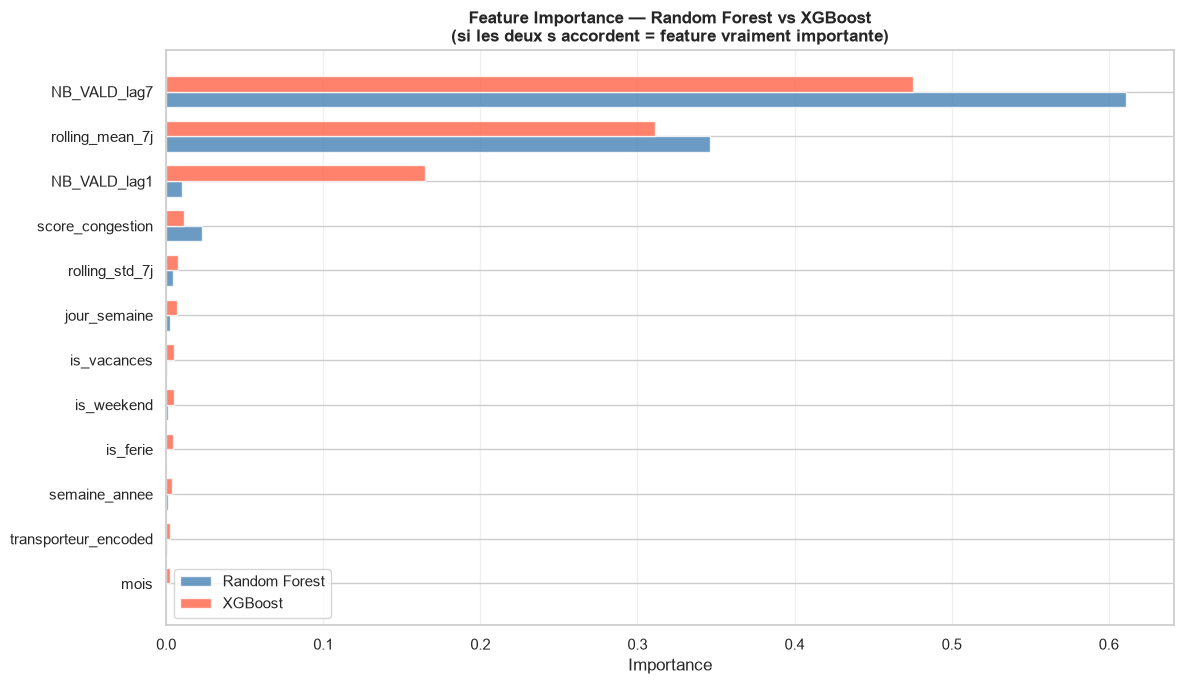

In [31]:
# Comparaison feature importance — RF vs XGBoost
# POURQUOI COMPARER ?
# Si RF et XGBoost s'accordent sur les features importantes
# => ces features sont vraiment importantes (robustesse)
# Si elles divergent => à investiguer

imp_rf  = pd.Series(model_rf.feature_importances_,  index=FEATURES)
imp_xgb = pd.Series(model_xgb.feature_importances_, index=FEATURES)
imp_df  = pd.DataFrame({'RandomForest': imp_rf, 'XGBoost': imp_xgb}).sort_values('XGBoost')

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(imp_df))
w = 0.35
ax.barh(x - w/2, imp_df['RandomForest'], w, label='Random Forest', color='steelblue', alpha=0.8)
ax.barh(x + w/2, imp_df['XGBoost'],      w, label='XGBoost',       color='tomato',    alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(imp_df.index)
ax.set_xlabel('Importance')
ax.set_title('Feature Importance — Random Forest vs XGBoost\n'
             '(si les deux s accordent = feature vraiment importante)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [33]:
# RÉSUMÉ FINAL
print('=' * 60)
print('RÉSUMÉ MODÈLE 1 — Prédiction du trafic IDFM')
print('=' * 60)

best_idx = resultats['R2_test'].idxmax()
best     = resultats.iloc[best_idx]

print(f"""
DATASET
  {len(df):,} lignes | 772 arrêts | 92 jours
  Train : {len(train):,} lignes | Test : {len(test):,} lignes
  Split temporel (pas aléatoire)

RÉSULTATS
  LinearRegression : R²={metrics_test_lr['R2']:.4f} | RMSE={metrics_test_lr['RMSE']:,.0f}
  DecisionTree     : R²={metrics_test_dt['R2']:.4f} | RMSE={metrics_test_dt['RMSE']:,.0f}
  RandomForest     : R²={metrics_test_rf['R2']:.4f} | RMSE={metrics_test_rf['RMSE']:,.0f}
  XGBoost          : R²={metrics_test_xgb['R2']:.4f} | RMSE={metrics_test_xgb['RMSE']:,.0f}

MEILLEUR MODÈLE : {best['Modèle']}
  R² test  = {best['R2_test']:.4f}
  RMSE test = {best['RMSE_test']:,.0f} validations
  Statut   = {best['Statut']}

MODÈLE SAUVEGARDÉ : models/traffic_model.pkl

PROCHAINE ÉTAPE : Modèle 2 — Détection d anomalies (Isolation Forest)
""")

RÉSUMÉ MODÈLE 1 — Prédiction du trafic IDFM

DATASET
  69,271 lignes | 772 arrêts | 92 jours
  Train : 54,730 lignes | Test : 14,541 lignes
  Split temporel (pas aléatoire)

RÉSULTATS
  LinearRegression : R²=0.9536 | RMSE=3,229
  DecisionTree     : R²=0.9668 | RMSE=2,730
  RandomForest     : R²=0.9847 | RMSE=1,857
  XGBoost          : R²=0.9491 | RMSE=3,381

MEILLEUR MODÈLE : RandomForest
  R² test  = 0.9847
  RMSE test = 1,857 validations
  Statut   = OK (ecart R²=0.012)

MODÈLE SAUVEGARDÉ : models/traffic_model.pkl

PROCHAINE ÉTAPE : Modèle 2 — Détection d anomalies (Isolation Forest)

